In [1]:
# Подключение пакетов
import Pkg
Pkg.add("JuMP")
Pkg.add("GLPK")
using JuMP
using GLPK

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed CodecBzip2 ─────── v0.8.5
   Installed StructTypes ────── v1.11.0
   Installed JSON3 ──────────── v1.14.3
   Installed MathOptInterface ─ v1.48.0
   Installed JuMP ───────────── v1.29.3
    Updating `~/.julia/environments/v1.11/Project.toml`
  [4076af6c] + JuMP v1.29.3
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [523fee87] + CodecBzip2 v0.8.5
  [0f8b85d8] + JSON3 v1.14.3
  [4076af6c] + JuMP v1.29.3
  [b8f27783] + MathOptInterface v1.48.0
  [856f2bd8] + StructTypes v1.11.0
Precompiling project...
   3704.7 ms  ✓ StructTypes
   3757.5 ms  ✓ CodecBzip2
   1183.7 ms  ✓ CategoricalArrays → CategoricalArraysStructTypesExt
   9109.5 ms  ✓ JSON3
   2491.1 ms  ✓ PlotlyBase → JSON3Ext
   2986.2 ms  ✓ PlotlyJS → JSON3Ext
  46867.7 ms  ✓ MathOptInterface
   1682.7 ms  ✓ Optim → OptimMOIExt
  23168.9 ms  ✓ JuMP
   2538.1 ms  ✓ SparseMatrixColorings → SparseMatrixColoringsJuMPExt


In [2]:
# Определение объекта модели с именем model
model = Model(GLPK.Optimizer)

A JuMP Model
├ solver: GLPK
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [3]:
# Определение переменных x, y и граничных условий для них
@variable(model, x >= 0)
@variable(model, y >= 0)

y

In [5]:
# Определение ограничений модели
@constraint(model, 6x + 8y >= 100)
@constraint(model, 7x + 12y >= 120)

7 x + 12 y ≥ 120

In [6]:
# Определение целевой функции
@objective(model, Min, 12x + 20y)

12 x + 20 y

In [7]:
# Вызов функции оптимизации
optimize!(model)

In [8]:
# Определение причины завершения работы оптимизатора
termination_status(model)

OPTIMAL::TerminationStatusCode = 1

In [9]:
# Демнострация превичных результирующих значений переменных x и y
@show value(x);
@show value(y);
# Демнострация результата оптимизации
@show objective_value(model);

value(x) = 14.999999999999993
value(y) = 1.2500000000000047
objective_value(model) = 205.0


In [10]:
# Подключение пакетов
import Pkg
Pkg.add("JuMP")
Pkg.add("GLPK")
using JuMP
using GLPK

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [11]:
# Определение объекта модели с именем vector_model
vector_model = Model(GLPK.Optimizer)

A JuMP Model
├ solver: GLPK
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [13]:
# Определение начальных данных
A = [1 1 19 5;
    3 5 0 8;
    2 0 6 13]
b = [7; 3; 5]
c = [1; 3; 5; 2]

4-element Vector{Int64}:
 1
 3
 5
 2

In [17]:
# Определение вектора переменных
@variable(vector_model, x[1:4] >= 0)

LoadError: An object of name x is already attached to this model. If this
    is intended, consider using the anonymous construction syntax, for example,
    `x = @variable(model, [1:N], ...)` where the name of the object does
    not appear inside the macro.

    Alternatively, use `unregister(model, :x)` to first unregister
    the existing name from the model. Note that this will not delete the
    object; it will just remove the reference at `model[:x]`.


In [18]:
# Определение ограничений модели
@constraint(vector_model, A * x .== b)

3-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[1] + x[2] + 19 x[3] + 5 x[4] = 7
 3 x[1] + 5 x[2] + 8 x[4] = 3
 2 x[1] + 6 x[3] + 13 x[4] = 5

In [19]:
# Определение целевой функции
@objective(vector_model, Min, c' * x)

x[1] + 3 x[2] + 5 x[3] + 2 x[4]

In [20]:
optimize!(vector_model)

In [21]:
# Определение причины завершения работы оптимизатора
termination_status(vector_model)

OPTIMAL::TerminationStatusCode = 1

In [25]:
# Демнострация результата оптимизации
@show objective_value(vector_model);

objective_value(vector_model) = 2.3746835443037977


In [26]:
# Подключение пакетов
import Pkg
Pkg.add("JuMP")
Pkg.add("GLPK")
using JuMP
using GLPK

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [27]:
# Контейнер для хранения данных об ограничениях 
# на количество потребляемых калорий, белков, жиров и соли
category_data = JuMP.Containers.DenseAxisArray(
    [1800 2200;
     91 Inf;
     0 65;
     0 1779],
    ["calories", "protein", "fat", "sodium"],
    ["min", "max"]
)

2-dimensional DenseAxisArray{Float64,2,...} with index sets:
    Dimension 1, ["calories", "protein", "fat", "sodium"]
    Dimension 2, ["min", "max"]
And data, a 4×2 Matrix{Float64}:
 1800.0  2200.0
   91.0    Inf
    0.0    65.0
    0.0  1779.0

In [29]:
# Массив данных с наименованиями продуктов
foods = ["hamburger", "chicken", "hot dog", "fries", "macaroni",
"pizza", "salad", "milk", "ice cream"];

In [30]:
# Массив стоимости продуктов
cost = JuMP.Containers.DenseAxisArray(
    [2.49, 2.89, 1.50, 1.89, 2.09, 1.99, 2.49, 0.89, 1.59],
    foods
)

1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, ["hamburger", "chicken", "hot dog", "fries", "macaroni", "pizza", "salad", "milk", "ice cream"]
And data, a 9-element Vector{Float64}:
 2.49
 2.89
 1.5
 1.89
 2.09
 1.99
 2.49
 0.89
 1.59

In [31]:
# Массив данных о содержании калорий, белков, жиров и соли в
# в продуктах питания
food_data = JuMP.Containers.DenseAxisArray(
    [410 24 26 730;
    420 32 10 1190;
    560 20 32 1800;
    380 4 19 270;
    320 12 10 930;
    320 15 12 820;
    320 31 12 1230;
    100 8 2.5 125;
    330 8 10 180],
    foods,
    ["calories", "protein", "fat", "sodium"]
)

2-dimensional DenseAxisArray{Float64,2,...} with index sets:
    Dimension 1, ["hamburger", "chicken", "hot dog", "fries", "macaroni", "pizza", "salad", "milk", "ice cream"]
    Dimension 2, ["calories", "protein", "fat", "sodium"]
And data, a 9×4 Matrix{Float64}:
 410.0  24.0  26.0   730.0
 420.0  32.0  10.0  1190.0
 560.0  20.0  32.0  1800.0
 380.0   4.0  19.0   270.0
 320.0  12.0  10.0   930.0
 320.0  15.0  12.0   820.0
 320.0  31.0  12.0  1230.0
 100.0   8.0   2.5   125.0
 330.0   8.0  10.0   180.0

In [32]:
# Определение объекта модели с именем model
model = Model(GLPK.Optimizer)

A JuMP Model
├ solver: GLPK
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [33]:
# Определим массив
categories = ["calories", "protein", "fat", "sodium"]

4-element Vector{String}:
 "calories"
 "protein"
 "fat"
 "sodium"

In [34]:
# Определение переменных
@variables(model, begin
    category_data[c, "min"] <= nutrition[c = categories] <= 
    category_data[c, "max"]
    # Сколько покупать продуктов
    buy[foods] >= 0
    end)

(1-dimensional DenseAxisArray{VariableRef,1,...} with index sets:
    Dimension 1, ["calories", "protein", "fat", "sodium"]
And data, a 4-element Vector{VariableRef}:
 nutrition[calories]
 nutrition[protein]
 nutrition[fat]
 nutrition[sodium], 1-dimensional DenseAxisArray{VariableRef,1,...} with index sets:
    Dimension 1, ["hamburger", "chicken", "hot dog", "fries", "macaroni", "pizza", "salad", "milk", "ice cream"]
And data, a 9-element Vector{VariableRef}:
 buy[hamburger]
 buy[chicken]
 buy[hot dog]
 buy[fries]
 buy[macaroni]
 buy[pizza]
 buy[salad]
 buy[milk]
 buy[ice cream])

In [35]:
# Определение целевой функции
@objective(model, Min, sum(cost[f] * buy[f] for f in foods))

2.49 buy[hamburger] + 2.89 buy[chicken] + 1.5 buy[hot dog] + 1.89 buy[fries] + 2.09 buy[macaroni] + 1.99 buy[pizza] + 2.49 buy[salad] + 0.89 buy[milk] + 1.59 buy[ice cream]

In [36]:
# Определение ограничений модели
@constraint(model, [c in categories],
sum(food_data[f, c] * buy[f] for f in foods) == nutrition[c])

1-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape},1,...} with index sets:
    Dimension 1, ["calories", "protein", "fat", "sodium"]
And data, a 4-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 -nutrition[calories] + 410 buy[hamburger] + 420 buy[chicken] + 560 buy[hot dog] + 380 buy[fries] + 320 buy[macaroni] + 320 buy[pizza] + 320 buy[salad] + 100 buy[milk] + 330 buy[ice cream] = 0
 -nutrition[protein] + 24 buy[hamburger] + 32 buy[chicken] + 20 buy[hot dog] + 4 buy[fries] + 12 buy[macaroni] + 15 buy[pizza] + 31 buy[salad] + 8 buy[milk] + 8 buy[ice cream] = 0
 -nutrition[fat] + 26 buy[hamburger] + 10 buy[chicken] + 32 buy[hot dog] + 19 buy[fries] + 10 buy[macaroni] + 12 buy[pizza] + 12 buy[salad] + 2.5 buy[milk] + 10 buy[ice cream] = 0
 -n

In [37]:
# Вызов функции оптимизации
JuMP.optimize!(model)
term_status = JuMP.termination_status(model)

OPTIMAL::TerminationStatusCode = 1

In [38]:
hcat(buy.data, JuMP.value.(buy.data))

9×2 Matrix{AffExpr}:
 buy[hamburger]  0.6045138888888888
 buy[chicken]    0
 buy[hot dog]    0
 buy[fries]      0
 buy[macaroni]   0
 buy[pizza]      0
 buy[salad]      0
 buy[milk]       6.9701388888888935
 buy[ice cream]  2.591319444444441

In [39]:
# Скачиваем данные с ресурса на git
;git clone https://github.com/ilyankou/passport-index-dataset.git

LoadError: ParseError:
[90m# Error @ [0;0m]8;;file:///home/aeaskerov/work/study/2025-2026/Компьютерный практикум по статистическому анализу данных/computer-practice/labs/lab8/In[39]#2:5\[90mIn[39]:2:5[0;0m]8;;\
# Скачиваем данные с ресурса на git
;git[48;2;120;70;70m clone https://github.com/ilyankou/passport-index-dataset.git[0;0m
[90m#   └───────────────────────────────────────────────────────────┘ ── [0;0m[91mextra tokens after end of expression[0;0m

In [40]:
# Подключение пакетов
import Pkg
Pkg.add("DelimitedFiles")
Pkg.add("CSV")
using DelimitedFiles
using CSV

   Resolving package versions...
    Updating `~/.julia/environments/v1.11/Project.toml`
  [8bb1440f] + DelimitedFiles v1.9.1
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [43]:
# Считывание данных
passportdata = readdlm(joinpath("passport-index-dataset", 
        "passport-index-matrix.csv"), ',')

200×200 Matrix{Any}:
 "Passport"                "Albania"        …    "Afghanistan"
 "Afghanistan"             "visa required"     -1
 "Albania"               -1                      "visa required"
 "Algeria"                 "visa required"       "visa required"
 "Andorra"               90                      "visa required"
 "Angola"                  "visa required"  …    "visa required"
 "Antigua and Barbuda"   90                      "visa required"
 "Argentina"             90                      "visa required"
 "Armenia"               90                      "visa required"
 "Australia"             90                      "visa required"
 "Austria"               90                 …    "visa required"
 "Azerbaijan"            90                      "visa required"
 "Bahamas"               90                      "visa required"
 ⋮                                          ⋱  
 "United Arab Emirates"  90                      "visa required"
 "United Kingdom"        90           

In [44]:
# Подключение пакетов
import Pkg
Pkg.add("JuMP")
Pkg.add("GLPK")
using JuMP
using GLPK

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [45]:
# Задаём переменные
cntr = passportdata[2:end,1]
vf = (x -> typeof(x)==Int64 || x == "VF" || x == "VOA" ? 
    1 : 0).(passportdata[2:end, 2:end]);

In [46]:
# Определение объекта модели с именем model
model = Model(GLPK.Optimizer)

A JuMP Model
├ solver: GLPK
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [47]:
# Переменные, ограничения и целевая функция
@variable(model, pass[1:length(cntr)], Bin)
@constraint(model, [j=1:length(cntr)], sum(vf[i, j]*pass[i] for i
            in 1:length(cntr)) >= 1)
@objective(model, Min, sum(pass))

pass[1] + pass[2] + pass[3] + pass[4] + pass[5] + pass[6] + pass[7] + pass[8] + pass[9] + pass[10] + pass[11] + pass[12] + pass[13] + pass[14] + pass[15] + pass[16] + pass[17] + pass[18] + pass[19] + pass[20] + pass[21] + pass[22] + pass[23] + pass[24] + pass[25] + pass[26] + pass[27] + pass[28] + pass[29] + pass[30] + [[...139 terms omitted...]] + pass[170] + pass[171] + pass[172] + pass[173] + pass[174] + pass[175] + pass[176] + pass[177] + pass[178] + pass[179] + pass[180] + pass[181] + pass[182] + pass[183] + pass[184] + pass[185] + pass[186] + pass[187] + pass[188] + pass[189] + pass[190] + pass[191] + pass[192] + pass[193] + pass[194] + pass[195] + pass[196] + pass[197] + pass[198] + pass[199]

In [48]:
# Вызов функции оптимизации
JuMP.optimize!(model)
termination_status(model)

OPTIMAL::TerminationStatusCode = 1

In [49]:
# Просмотр результата
print(JuMP.objective_value(model), " passports: ", 
    join(cntr[findall(JuMP.value.(pass) .== 1)], ", "))

63.0 passports: Afghanistan, Andorra, Argentina, Australia, Azerbaijan, Bahrain, Brunei, Cambodia, Cameroon, Canada, Chile, Colombia, Comoros, DR Congo, Djibouti, Equatorial Guinea, Eritrea, Fiji, Gabon, Georgia, Guinea, Guinea-Bissau, Hong Kong, Hungary, Indonesia, Iraq, Ireland, Israel, Jamaica, Japan, Kuwait, Laos, Liberia, Libya, Macao, Madagascar, Malaysia, Maldives, Marshall Islands, Mauritania, Mauritius, Mongolia, Mozambique, Nauru, Nepal, New Zealand, North Korea, Palestine, Papua New Guinea, Qatar, Saudi Arabia, Solomon Islands, Somalia, South Sudan, Sri Lanka, Syria, Taiwan, Timor-Leste, Togo, Turkmenistan, United States, Uruguay, Vietnam

In [50]:
# Подключение необходимых пакетов
import Pkg
Pkg.add("DataFrames")
Pkg.add("XLSX")
Pkg.add("Plots")
Pkg.add("PyPlot")
Pkg.add("Convex")
Pkg.add("SCS")
Pkg.add("Statistics")
using DataFrames
using XLSX
using Plots
pyplot()
using Convex
using SCS
using Statistics

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
   Installed ZipArchives ──── v2.6.0
   Installed XML2_jll ─────── v2.15.1+0
   Installed ZipFile ──────── v0.10.1
   Installed CodecInflate64 ─ v0.1.3
   Installed InputBuffers ─── v1.1.1
   Installed EzXML ────────── v1.2.3
   Installed XLSX ─────────── v0.10.4
   Installed ArgCheck ─────── v2.5.0
    Updating `~/.julia/environments/v1.11/Project.toml`
  [fdbf4ff8] + XLSX v0.10.4
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [dce04be8] + ArgCheck v2.5.0
  [6309b1aa] + CodecInflate64 v0.1.3
  [8f5d6c58] + EzXML v1.2.3
  [0c81fc1b] + InputBuffers v1.1.1
  [fdbf4ff8] + XLSX v0.10.4
  [49080126] + ZipArchives v2.6.0
  [a5390f91] + ZipFile v0.10.1
  [02c8fc9c] + XML2_jll v2.15.1+0
Precompiling project...
   2309.4 ms  ✓ ArgCheck
   1895.8 ms  ✓ CodecInflate64
   1892.3 ms  ✓ ZipFile
   1496.6 m

In [52]:
# Считываем данные и размещаем их во фрейм
T = DataFrame(XLSX.readtable("data/stock_prices.xlsx", "Sheet2"))

Row,MSFT,FB,AAPL
,Any,Any,Any
1,101.93,137.95,148.26
2,102.8,143.8,152.29
3,107.71,150.04,156.82
4,107.17,149.01,157.76
5,102.78,165.71,166.52
6,105.67,167.33,170.41
7,108.22,162.5,170.42
8,110.97,161.89,172.97
9,112.53,162.28,174.97


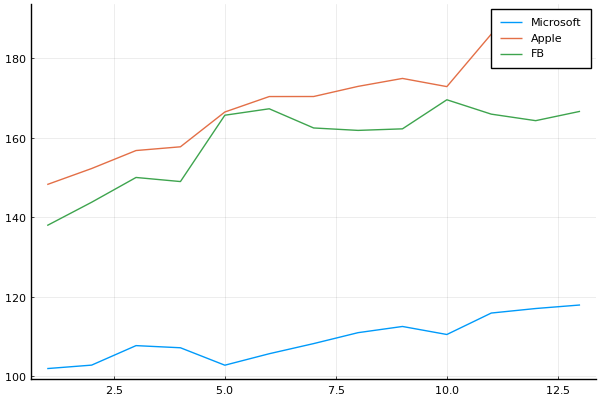

In [54]:
# Построение графика
plot(T[!,:MSFT], label="Microsoft")
plot!(T[!,:AAPL], label="Apple")
plot!(T[!,:FB], label="FB")

In [55]:
# Данные о ценах на акции размещаем в матрице
prices_matrix = Matrix(T)

13×3 Matrix{Any}:
 101.93  137.95  148.26
 102.8   143.8   152.29
 107.71  150.04  156.82
 107.17  149.01  157.76
 102.78  165.71  166.52
 105.67  167.33  170.41
 108.22  162.5   170.42
 110.97  161.89  172.97
 112.53  162.28  174.97
 110.51  169.6   172.91
 115.91  165.98  186.12
 117.05  164.34  191.05
 117.94  166.69  189.95

In [57]:
# Вычисление матрицы доходностей за период времени
M1 = prices_matrix[1:end-1,:]
M2 = prices_matrix[2:end,:]
# Матрица доходностей
R = (M2.-M1)./M1

12×3 Matrix{Float64}:
  0.00853527   0.0424067    0.027182
  0.0477626    0.0433936    0.0297459
 -0.00501346  -0.00686484   0.00599413
 -0.040963     0.112073     0.0555274
  0.0281183    0.00977611   0.0233606
  0.0241317   -0.0288651    5.8682e-5
  0.0254112   -0.00375385   0.014963
  0.0140579    0.00240904   0.0115627
 -0.0179508    0.0451072   -0.0117734
  0.0488644   -0.0213443    0.0763981
  0.00983522  -0.00988071   0.0264883
  0.00760359   0.0142996   -0.00575766

In [58]:
# Матрица рисков
risk_matrix = cov(R)
# Проверка положительной определённости матрицы рисков
isposdef(risk_matrix)

true

In [59]:
# Доход от каждой из компаний
r = mean(R, dims=1)[:]

3-element Vector{Float64}:
 0.012532748705136576
 0.016563036855293173
 0.021145804655032917

In [60]:
# Вектор инвестиций
x = Variable(length(r))

Variable
size: (3, 1)
sign: real
vexity: affine
id: 154…682

In [61]:
# Объект модели
problem = minimize(Convex.quadform(x, risk_matrix),
    [sum(x) == 1; r'*x >= 0.02; x .>= 0])

Problem statistics
  problem is DCP         : true
  number of variables    : 1 (3 scalar elements)
  number of constraints  : 5 (5 scalar elements)
  number of coefficients : 19
  number of atoms        : 14

Solution summary
  termination status : OPTIMIZE_NOT_CALLED
  primal status      : NO_SOLUTION
  dual status        : NO_SOLUTION

Expression graph
  minimize
   └─ * (convex; positive)
      ├─ [1;;]
      └─ qol_elem (convex; positive)
         ├─ norm2 (convex; positive)
         │  └─ …
         └─ [1.0;;]
  subject to
   ├─ == constraint (affine)
   │  └─ + (affine; real)
   │     ├─ sum (affine; real)
   │     │  └─ …
   │     └─ [-1;;]
   ├─ ≥ constraint (affine)
   │  └─ + (affine; real)
   │     ├─ * (affine; real)
   │     │  ├─ …
   │     │  └─ …
   │     └─ [-0.02;;]
   ├─ ≥ constraint (affine)
   │  └─ + (affine; real)
   │     ├─ index (affine; real)
   │     │  └─ …
   │     └─ [0;;]
   ⋮


In [62]:
# Находим решение
solve!(problem, SCS.Optimizer)

[ Info: [Convex.jl] Compilation finished: 10.45 seconds, 801.209 MiB of memory allocated


------------------------------------------------------------------
	       SCS v3.2.9 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 5, constraints m: 12
cones: 	  z: primal zero / dual free vars: 1
	  l: linear vars: 4
	  q: soc vars: 7, qsize: 2
settings: eps_abs: 1.0e-04, eps_rel: 1.0e-04, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
	  compiled with openmp parallelization enabled
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 22, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   gap   |   obj   |  scale  | time (s)
------------------------------------------------------------------
     0| 1.45e+01  1.00e+00  2.01e+01 -9.96e+00  1.00e-01  3.39e-03 
    75| 1.70e-04  3.73e-05  5.25

Problem statistics
  problem is DCP         : true
  number of variables    : 1 (3 scalar elements)
  number of constraints  : 5 (5 scalar elements)
  number of coefficients : 19
  number of atoms        : 14

Solution summary
  termination status : OPTIMAL
  primal status      : FEASIBLE_POINT
  dual status        : FEASIBLE_POINT
  objective value    : 0.0005

Expression graph
  minimize
   └─ * (convex; positive)
      ├─ [1;;]
      └─ qol_elem (convex; positive)
         ├─ norm2 (convex; positive)
         │  └─ …
         └─ [1.0;;]
  subject to
   ├─ == constraint (affine)
   │  └─ + (affine; real)
   │     ├─ sum (affine; real)
   │     │  └─ …
   │     └─ [-1;;]
   ├─ ≥ constraint (affine)
   │  └─ + (affine; real)
   │     ├─ * (affine; real)
   │     │  ├─ …
   │     │  └─ …
   │     └─ [-0.02;;]
   ├─ ≥ constraint (affine)
   │  └─ + (affine; real)
   │     ├─ index (affine; real)
   │     │  └─ …
   │     └─ [0;;]
   ⋮


In [63]:
x

Variable
size: (3, 1)
sign: real
vexity: affine
id: 154…682
value: [0.07740709795031134, 0.11606771003983696, 0.8065276266877964]

In [64]:
sum(x.value)

1.0000024346779448

In [65]:
r' * x.value

1×1 adjoint(::Vector{Float64}) with eltype Float64:
 0.0199472331085319

In [66]:
x.value .* 1000

3×1 Matrix{Float64}:
  77.40709795031134
 116.06771003983695
 806.5276266877964

In [68]:
# Подключение необходимых пакетов
import Pkg
Pkg.add("ImageMagick")
Pkg.add("Images")
Pkg.add("Convex")
Pkg.add("SCS")
using Images
using Convex
using SCS

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
   Installed ImageSegmentation ───────── v1.10.0
   Installed HistogramThresholding ───── v0.3.1
   Installed TiledIteration ──────────── v0.5.0
   Installed FFTW ────────────────────── v1.10.0
   Installed ScopedValues ────────────── v1.5.0
   Installed RegionTrees ─────────────── v0.3.2
   Installed Images ──────────────────── v0.26.2
   Installed ChunkCodecLibZstd ───────── v1.0.0
   Installed SLEEFPirates ────────────── v0.6.43
   Installed RealDot ─────────────────── v0.1.0
   Installed CustomUnitRanges ────────── v1.0.2
   Installed MetaGraphs ──────────────── v0.8.1
   Installed Polynomials ─────────────── v4.1.0
   Installed JLD2 ────────────────────── v0.6.3
   Installed ComputationalResources ──── v0.3.2
   Installed Ratios ──────────────────── v0.4.5
   Installed Graphics ────────────────── v1

  46369.9 ms  ✓ LoopVectorization
   2431.2 ms  ✓ LoopVectorization → ForwardDiffExt
   3810.5 ms  ✓ LoopVectorization → SpecialFunctionsExt
  66880.4 ms  ✓ JLD2
   2059.0 ms  ✓ JLD2 → UnPackExt
   2852.6 ms  ✓ MetaGraphs
   7232.9 ms  ✓ ImageMorphology
   1787.3 ms  ✓ ImageDistances
  86502.3 ms  ✓ ImageFiltering
   4743.7 ms  ✓ ImageSegmentation
  12594.8 ms  ✓ ImageCorners
  15422.4 ms  ✓ ImageQualityIndexes
   5261.9 ms  ✓ Images
  55 dependencies successfully precompiled in 140 seconds. 645 already precompiled.
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


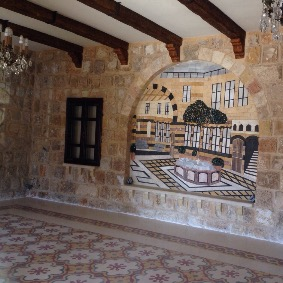

In [69]:
# Считывание исходного изображения
Kref = load("data/khiam-small.jpg")

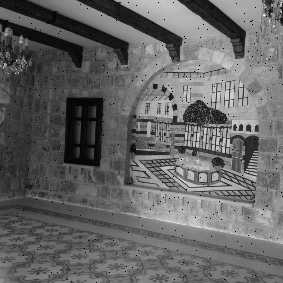

In [72]:
# Испортим некоторые пиксели
K = copy(Kref)
p = prod(size(K))
missingids = rand(1:p, 400)
K[missingids] .= RGBX{N0f8}(0.0, 0.0, 0.0)
K
Gray.(K)

In [73]:
# Матрица цветов
Y = Float64.(Gray.(K));

In [75]:
# Сформируем новую матрицу
correctids = findall(Y[:].!=0)
X = Convex.Variable(size(Y))
problem = minimize(nuclearnorm(X))
problem.constraints += X[correctids]==Y[correctids]

┌ Warning: Concatenating collections of constraints together with `+` or `+=` to produce a new list of constraints is deprecated. Instead, use `vcat` to concatenate collections of constraints.
└ @ Convex ~/.julia/packages/Convex/IPPoR/src/deprecations.jl:129


1-element Vector{Constraint}:
 == constraint (affine)
└─ + (affine; real)
   ├─ index (affine; real)
   │  └─ 283×283 real variable (id: 743…730)
   └─ 79689×1 Matrix{Float64}

In [79]:
# Находим решение
solve!(problem, SCS.Optimizer)

[ Info: [Convex.jl] Compilation finished: 3.51 seconds, 276.839 MiB of memory allocated


------------------------------------------------------------------
	       SCS v3.2.9 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 80090, constraints m: 159779
cones: 	  z: primal zero / dual free vars: 79689
	  nuc: nuclear vars: 80090, nucsize: 1
settings: eps_abs: 1.0e-04, eps_rel: 1.0e-04, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
	  compiled with openmp parallelization enabled
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 159779, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   gap   |   obj   |  scale  | time (s)
------------------------------------------------------------------
     0| 1.27e+02  1.17e+01  3.09e+03  1.53e+03  1.00e-01  2.91e-01 
   150| 4.78e-03  6.00e-0

Problem statistics
  problem is DCP         : true
  number of variables    : 1 (80_089 scalar elements)
  number of constraints  : 1 (79_689 scalar elements)
  number of coefficients : 79_689
  number of atoms        : 3

Solution summary
  termination status : OPTIMAL
  primal status      : FEASIBLE_POINT
  dual status        : FEASIBLE_POINT
  objective value    : 445.3978

Expression graph
  minimize
   └─ nuclearnorm (convex; positive)
      └─ 283×283 real variable (id: 743…730)
  subject to
   └─ == constraint (affine)
      └─ + (affine; real)
         ├─ index (affine; real)
         │  └─ …
         └─ 79689×1 Matrix{Float64}


norm(float.(Gray.(Kref)) - X.value) = 1.1122718131375837
norm(-(X.value)) = 124.34078864729219


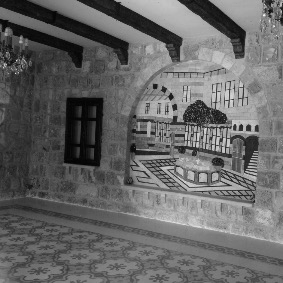

In [81]:
# Значение нормы и исправленное изображение
@show norm(float.(Gray.(Kref))-X.value)
@show norm(-X.value)
colorview(Gray, X.value)

In [82]:
# №1
# Определение объекта модели с именем model
model = Model(GLPK.Optimizer)

A JuMP Model
├ solver: GLPK
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [83]:
# Определение переменных x, y и граничных условий для них
@variable(model, 0 <= x1 <= 10)
@variable(model, x2 >= 0)
@variable(model, x3 >= 0)

x3

In [84]:
# Определение ограничений модели
@constraint(model, -x1 + x2 + 3x3 <= -5)
@constraint(model, x1 + 3x2 - 7x3 <= 10)

x1 + 3 x2 - 7 x3 ≤ 10

In [86]:
# Определение целевой функции
@objective(model, Max, x1 + 2x2 + 5x3)

x1 + 2 x2 + 5 x3

In [87]:
# Вызов функции оптимизации
optimize!(model)
# Определение причины завершения работы оптимизатора
termination_status(model)

OPTIMAL::TerminationStatusCode = 1

In [90]:
# Демонстрация первичных результирующих значений переменных x и y
@show value(x1);
@show value(x2);
@show value(x3);

value(x1) = 10.0
value(x2) = 2.1875
value(x3) = 0.9375


In [92]:
# №2
# Определение объекта модели с именем model
vector_model = Model(GLPK.Optimizer)

A JuMP Model
├ solver: GLPK
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [93]:
A = [-1 1 3; 1 3 -7]
b = [-5; 10]
c = [1; 2; 5]

3-element Vector{Int64}:
 1
 2
 5

In [94]:
@variable(vector_model, x[1:3] >= 0)

3-element Vector{VariableRef}:
 x[1]
 x[2]
 x[3]

In [95]:
# Определение ограничений модели
@constraint(vector_model, A*x .<= b)
@constraint(vector_model, x[1] <= 10)

x[1] ≤ 10

In [96]:
# Определение целевой функции
@objective(vector_model, Max, c' * x)

x[1] + 2 x[2] + 5 x[3]

In [97]:
# Вызов функции оптимизации
optimize!(vector_model)
# Определение причины завершения работы оптимизатора
termination_status(vector_model)

OPTIMAL::TerminationStatusCode = 1

In [98]:
# Демонстрация первичных результирующих значений переменных x и y
@show value(x1);
@show value(x2);
@show value(x3);

value(x1) = 10.0
value(x2) = 2.1875
value(x3) = 0.9375


In [99]:
# №3
using Random
m = 10
n = 5

Random.seed!(42)
A = rand(m, n)
b = rand(m)

x = Variable(n)

objective = sumsquares(A*x-b)
constraints = [x >= 0]

problem = minimize(objective, constraints)

Problem statistics
  problem is DCP         : true
  number of variables    : 1 (5 scalar elements)
  number of constraints  : 1 (5 scalar elements)
  number of coefficients : 67
  number of atoms        : 6

Solution summary
  termination status : OPTIMIZE_NOT_CALLED
  primal status      : NO_SOLUTION
  dual status        : NO_SOLUTION

Expression graph
  minimize
   └─ qol (convex; positive)
      ├─ + (affine; real)
      │  ├─ * (affine; real)
      │  │  ├─ …
      │  │  └─ …
      │  └─ 10×1 Matrix{Float64}
      └─ [1;;]
  subject to
   └─ ≥ constraint (affine)
      └─ + (affine; real)
         ├─ 5-element real variable (id: 146…390)
         └─ Convex.NegateAtom (constant; negative)
            └─ …


In [100]:
solve!(problem, SCS.Optimizer)

[ Info: [Convex.jl] Compilation finished: 2.25 seconds, 175.393 MiB of memory allocated


------------------------------------------------------------------
	       SCS v3.2.9 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 6, constraints m: 17
cones: 	  l: linear vars: 5
	  q: soc vars: 12, qsize: 1
settings: eps_abs: 1.0e-04, eps_rel: 1.0e-04, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
	  compiled with openmp parallelization enabled
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 57, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   gap   |   obj   |  scale  | time (s)
------------------------------------------------------------------
     0| 1.76e+01  1.00e+00  2.45e+01 -1.21e+01  1.00e-01  1.03e-02 
   125| 1.17e-06  5.96e-07  2.76e-06  5.98e-01  1.42e+00  3.36e-02 
-

Problem statistics
  problem is DCP         : true
  number of variables    : 1 (5 scalar elements)
  number of constraints  : 1 (5 scalar elements)
  number of coefficients : 67
  number of atoms        : 6

Solution summary
  termination status : OPTIMAL
  primal status      : FEASIBLE_POINT
  dual status        : FEASIBLE_POINT
  objective value    : 0.598

Expression graph
  minimize
   └─ qol (convex; positive)
      ├─ + (affine; real)
      │  ├─ * (affine; real)
      │  │  ├─ …
      │  │  └─ …
      │  └─ 10×1 Matrix{Float64}
      └─ [1;;]
  subject to
   └─ ≥ constraint (affine)
      └─ + (affine; real)
         ├─ 5-element real variable (id: 146…390)
         └─ Convex.NegateAtom (constant; negative)
            └─ …


In [101]:
println("Статус задачи: ", problem.status)

Статус задачи: OPTIMAL


In [102]:
# №4
num_sections = 5
num_applications = 1000

min_capacity = [180, 180, 220, 180, 180]
max_capacity = [250, 250, 220, 250, 250]

Random.seed!(42)

priorities = [shuffle([1, 2, 3, 10000, 10000]) for _ 
        in 1:num_applications]
priorities = hcat(priorities...)'
priority_weights = sum(priorities, dims=1)

1×5 Matrix{Int64}:
 3851232  4091162  4181199  4031198  3851209

In [103]:
model = Model(GLPK.Optimizer)

A JuMP Model
├ solver: GLPK
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [104]:
@variables(model, begin
    180 <= x1 <= 250
    180 <= x2 <= 250
    x3 == 220
    180 <= x4 <= 250
    180 <= x5 <= 250
    end)

(x1, x2, x3, x4, x5)

In [106]:
@constraint(model, x1+x2+x3+x4+x5==1000)
@objective(model, Min, x1 * priority_weights[1] +
                        x2 * priority_weights[2] +
                        x3 * priority_weights[3] +
                        x4 * priority_weights[4] +
                        x5 * priority_weights[5])

3851232 x1 + 4091162 x2 + 4181199 x3 + 4031198 x4 + 3851209 x5

In [109]:
optimize!(model)
termination_status(model)

OPTIMAL::TerminationStatusCode = 1

In [110]:
println("x1: ", value(x1))
println("x2: ", value(x2))
println("x3: ", value(x3))
println("x4: ", value(x4))
println("x5: ", value(x5))
println("Оптимальное значение целевой функции: ", 
    objective_value(model))

x1: 180.0
x2: 180.0
x3: 220.0
x4: 180.0
x5: 240.0
Оптимальное значение целевой функции: 3.9994005e9


In [111]:
# №5
coffee = ["Raf", "Cappuccino"]
products = ["grains", "milk", "sugar"]

cost = JuMP.Containers.DenseAxisArray(
    [400, 300],
    coffee
)
coffee_data = JuMP.Containers.DenseAxisArray(
    [40 140 5;
    30 120 0],
    coffee,
    products
)
store = JuMP.Containers.DenseAxisArray([500, 2000, 40], products)

1-dimensional DenseAxisArray{Int64,1,...} with index sets:
    Dimension 1, ["grains", "milk", "sugar"]
And data, a 3-element Vector{Int64}:
  500
 2000
   40

In [112]:
model = Model(GLPK.Optimizer)
@variables(model, begin
    buy[coffee] >= 0
end)
@objective(model, Max, sum(cost[c] * buy[c] for c in coffee))
@constraint(model, [p in products],
    sum(coffee_data[c, p] * buy[c] for c in coffee) <= store[p])
@constraint(model, coffee_data["Raf", "sugar"] * buy["Raf"] == 40)

5 buy[Raf] = 40

In [114]:
JuMP.optimize!(model)
term_status = JuMP.termination_status(model)
hcat(buy.data, JuMP.value.(buy.data))

2×2 Matrix{AffExpr}:
 buy[Raf]         8
 buy[Cappuccino]  6